In [105]:
import pandas as pd
import numpy as np
from numpy import dtype
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("AmesHousing.csv")

In [3]:
df

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


In [4]:
df = df.drop(columns=['Order','PID'])

In [5]:
df.shape

(2930, 80)

In [6]:
print(df.head())

   MS SubClass MS Zoning  Lot Frontage  Lot Area Street Alley Lot Shape  \
0           20        RL         141.0     31770   Pave   NaN       IR1   
1           20        RH          80.0     11622   Pave   NaN       Reg   
2           20        RL          81.0     14267   Pave   NaN       IR1   
3           20        RL          93.0     11160   Pave   NaN       Reg   
4           60        RL          74.0     13830   Pave   NaN       IR1   

  Land Contour Utilities Lot Config  ... Pool Area Pool QC  Fence  \
0          Lvl    AllPub     Corner  ...         0     NaN    NaN   
1          Lvl    AllPub     Inside  ...         0     NaN  MnPrv   
2          Lvl    AllPub     Corner  ...         0     NaN    NaN   
3          Lvl    AllPub     Corner  ...         0     NaN    NaN   
4          Lvl    AllPub     Inside  ...         0     NaN  MnPrv   

  Misc Feature Misc Val Mo Sold  Yr Sold  Sale Type  Sale Condition  SalePrice  
0          NaN        0       5     2010        WD   

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 80 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      2930 non-null   int64  
 1   MS Zoning        2930 non-null   object 
 2   Lot Frontage     2440 non-null   float64
 3   Lot Area         2930 non-null   int64  
 4   Street           2930 non-null   object 
 5   Alley            198 non-null    object 
 6   Lot Shape        2930 non-null   object 
 7   Land Contour     2930 non-null   object 
 8   Utilities        2930 non-null   object 
 9   Lot Config       2930 non-null   object 
 10  Land Slope       2930 non-null   object 
 11  Neighborhood     2930 non-null   object 
 12  Condition 1      2930 non-null   object 
 13  Condition 2      2930 non-null   object 
 14  Bldg Type        2930 non-null   object 
 15  House Style      2930 non-null   object 
 16  Overall Qual     2930 non-null   int64  
 17  Overall Cond  

In [8]:
inventory = df.columns.to_series().groupby(df.dtypes).apply(list).to_dict()

In [9]:
df.dtypes.groupby(df.dtypes).groups

{int64: ['MS SubClass', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 'SalePrice'], float64: ['Lot Frontage', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Garage Yr Blt', 'Garage Cars', 'Garage Area'], object: ['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC', 'Central 

In [10]:
inventory

{dtype('int64'): ['MS SubClass',
  'Lot Area',
  'Overall Qual',
  'Overall Cond',
  'Year Built',
  'Year Remod/Add',
  '1st Flr SF',
  '2nd Flr SF',
  'Low Qual Fin SF',
  'Gr Liv Area',
  'Full Bath',
  'Half Bath',
  'Bedroom AbvGr',
  'Kitchen AbvGr',
  'TotRms AbvGrd',
  'Fireplaces',
  'Wood Deck SF',
  'Open Porch SF',
  'Enclosed Porch',
  '3Ssn Porch',
  'Screen Porch',
  'Pool Area',
  'Misc Val',
  'Mo Sold',
  'Yr Sold',
  'SalePrice'],
 dtype('float64'): ['Lot Frontage',
  'Mas Vnr Area',
  'BsmtFin SF 1',
  'BsmtFin SF 2',
  'Bsmt Unf SF',
  'Total Bsmt SF',
  'Bsmt Full Bath',
  'Bsmt Half Bath',
  'Garage Yr Blt',
  'Garage Cars',
  'Garage Area'],
 dtype('O'): ['MS Zoning',
  'Street',
  'Alley',
  'Lot Shape',
  'Land Contour',
  'Utilities',
  'Lot Config',
  'Land Slope',
  'Neighborhood',
  'Condition 1',
  'Condition 2',
  'Bldg Type',
  'House Style',
  'Roof Style',
  'Roof Matl',
  'Exterior 1st',
  'Exterior 2nd',
  'Mas Vnr Type',
  'Exter Qual',
  'Exter Co

In [11]:
num_cols = inventory[dtype('int64')] + inventory[dtype('float')]

In [12]:
num_cols

['MS SubClass',
 'Lot Area',
 'Overall Qual',
 'Overall Cond',
 'Year Built',
 'Year Remod/Add',
 '1st Flr SF',
 '2nd Flr SF',
 'Low Qual Fin SF',
 'Gr Liv Area',
 'Full Bath',
 'Half Bath',
 'Bedroom AbvGr',
 'Kitchen AbvGr',
 'TotRms AbvGrd',
 'Fireplaces',
 'Wood Deck SF',
 'Open Porch SF',
 'Enclosed Porch',
 '3Ssn Porch',
 'Screen Porch',
 'Pool Area',
 'Misc Val',
 'Mo Sold',
 'Yr Sold',
 'SalePrice',
 'Lot Frontage',
 'Mas Vnr Area',
 'BsmtFin SF 1',
 'BsmtFin SF 2',
 'Bsmt Unf SF',
 'Total Bsmt SF',
 'Bsmt Full Bath',
 'Bsmt Half Bath',
 'Garage Yr Blt',
 'Garage Cars',
 'Garage Area']

In [13]:
len(num_cols)

37

In [14]:
for i  in range(21,37):
    is_check = df[num_cols[i]].isnull().sum()
    print(df[num_cols[i]].name,is_check)

Pool Area 0
Misc Val 0
Mo Sold 0
Yr Sold 0
SalePrice 0
Lot Frontage 490
Mas Vnr Area 23
BsmtFin SF 1 1
BsmtFin SF 2 1
Bsmt Unf SF 1
Total Bsmt SF 1
Bsmt Full Bath 2
Bsmt Half Bath 2
Garage Yr Blt 159
Garage Cars 1
Garage Area 1


In [15]:
df['Lot Frontage'].unique()

array([141.,  80.,  81.,  93.,  74.,  78.,  41.,  43.,  39.,  60.,  75.,
        nan,  63.,  85.,  47., 152.,  88., 140., 105.,  65.,  70.,  26.,
        21.,  53.,  24., 102.,  98.,  83.,  94.,  95.,  90.,  79., 100.,
        44., 110.,  61.,  36.,  67., 108.,  59.,  92.,  58.,  56.,  73.,
        72.,  84.,  76.,  50.,  55.,  68., 107.,  25.,  30.,  57.,  40.,
        77., 120., 137.,  87., 119.,  64.,  96.,  71.,  69.,  52.,  51.,
        54.,  86., 124.,  82.,  38.,  48.,  89.,  66.,  45.,  35., 129.,
        31.,  42.,  28.,  99., 104.,  97., 103.,  34., 117., 149., 122.,
        62., 174., 106., 112.,  32., 115., 128.,  91.,  33., 121., 144.,
       130., 109., 150., 113., 125., 101.,  46., 114., 135., 136.,  37.,
        22., 313.,  49., 123., 160., 195., 118., 134., 182., 116., 138.,
       155., 126., 200., 168., 111., 131., 153., 133.])

[]

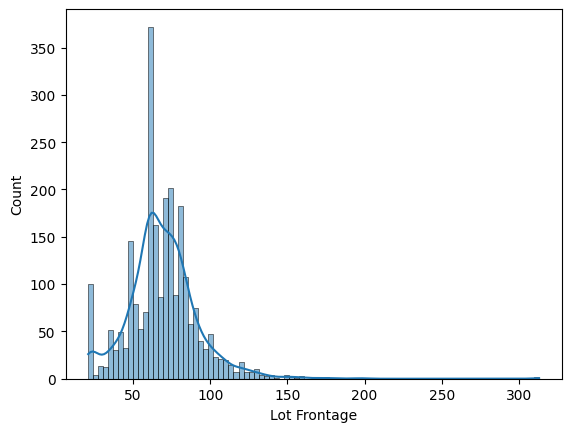

In [16]:
sns.histplot(df['Lot Frontage'], kde=True)
plt.plot()

In [17]:
df['Lot Frontage'].isnull().sum()

np.int64(490)

In [18]:
df['Neighborhood'].unique()

array(['NAmes', 'Gilbert', 'StoneBr', 'NWAmes', 'Somerst', 'BrDale',
       'NPkVill', 'NridgHt', 'Blmngtn', 'NoRidge', 'SawyerW', 'Sawyer',
       'Greens', 'BrkSide', 'OldTown', 'IDOTRR', 'ClearCr', 'SWISU',
       'Edwards', 'CollgCr', 'Crawfor', 'Blueste', 'Mitchel', 'Timber',
       'MeadowV', 'Veenker', 'GrnHill', 'Landmrk'], dtype=object)

#### Lot Frontage means The length of the property (in feet) that touches the street

In [19]:
df['Lot Frontage'].unique()

array([141.,  80.,  81.,  93.,  74.,  78.,  41.,  43.,  39.,  60.,  75.,
        nan,  63.,  85.,  47., 152.,  88., 140., 105.,  65.,  70.,  26.,
        21.,  53.,  24., 102.,  98.,  83.,  94.,  95.,  90.,  79., 100.,
        44., 110.,  61.,  36.,  67., 108.,  59.,  92.,  58.,  56.,  73.,
        72.,  84.,  76.,  50.,  55.,  68., 107.,  25.,  30.,  57.,  40.,
        77., 120., 137.,  87., 119.,  64.,  96.,  71.,  69.,  52.,  51.,
        54.,  86., 124.,  82.,  38.,  48.,  89.,  66.,  45.,  35., 129.,
        31.,  42.,  28.,  99., 104.,  97., 103.,  34., 117., 149., 122.,
        62., 174., 106., 112.,  32., 115., 128.,  91.,  33., 121., 144.,
       130., 109., 150., 113., 125., 101.,  46., 114., 135., 136.,  37.,
        22., 313.,  49., 123., 160., 195., 118., 134., 182., 116., 138.,
       155., 126., 200., 168., 111., 131., 153., 133.])

In [20]:
df['Lot Frontage'] =  df.groupby('Neighborhood')['Lot Frontage'].transform(
    lambda x: x.fillna(x.median())
)

C:\Users\patel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\patel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [21]:
df['Lot Frontage'].isnull().sum()

np.int64(3)

In [22]:
df['Lot Frontage'] = df['Lot Frontage'].fillna(df['Lot Frontage'].median())

In [23]:
for i  in range(27,37):
    df[num_cols[i]] = df[num_cols[i]].fillna(0)

In [24]:
cat_cols = inventory[dtype('object')]

In [25]:
cat_cols

['MS Zoning',
 'Street',
 'Alley',
 'Lot Shape',
 'Land Contour',
 'Utilities',
 'Lot Config',
 'Land Slope',
 'Neighborhood',
 'Condition 1',
 'Condition 2',
 'Bldg Type',
 'House Style',
 'Roof Style',
 'Roof Matl',
 'Exterior 1st',
 'Exterior 2nd',
 'Mas Vnr Type',
 'Exter Qual',
 'Exter Cond',
 'Foundation',
 'Bsmt Qual',
 'Bsmt Cond',
 'Bsmt Exposure',
 'BsmtFin Type 1',
 'BsmtFin Type 2',
 'Heating',
 'Heating QC',
 'Central Air',
 'Electrical',
 'Kitchen Qual',
 'Functional',
 'Fireplace Qu',
 'Garage Type',
 'Garage Finish',
 'Garage Qual',
 'Garage Cond',
 'Paved Drive',
 'Pool QC',
 'Fence',
 'Misc Feature',
 'Sale Type',
 'Sale Condition']

In [26]:
len(cat_cols)

43

In [27]:
cat_cols[1]

'Street'

In [28]:
df['MS Zoning'].unique()

array(['RL', 'RH', 'FV', 'RM', 'C (all)', 'I (all)', 'A (agr)'],
      dtype=object)

In [29]:
for i in range(11,22):
    is_check = df[cat_cols[i]].unique()
    print(df[cat_cols[i]].name,is_check)

Bldg Type ['1Fam' 'TwnhsE' 'Twnhs' 'Duplex' '2fmCon']
House Style ['1Story' '2Story' '1.5Fin' 'SFoyer' 'SLvl' '2.5Unf' '1.5Unf' '2.5Fin']
Roof Style ['Hip' 'Gable' 'Mansard' 'Gambrel' 'Shed' 'Flat']
Roof Matl ['CompShg' 'WdShake' 'Tar&Grv' 'WdShngl' 'Membran' 'ClyTile' 'Roll'
 'Metal']
Exterior 1st ['BrkFace' 'VinylSd' 'Wd Sdng' 'CemntBd' 'HdBoard' 'Plywood' 'MetalSd'
 'AsbShng' 'WdShing' 'Stucco' 'AsphShn' 'BrkComm' 'CBlock' 'PreCast'
 'Stone' 'ImStucc']
Exterior 2nd ['Plywood' 'VinylSd' 'Wd Sdng' 'BrkFace' 'CmentBd' 'HdBoard' 'Wd Shng'
 'MetalSd' 'ImStucc' 'Brk Cmn' 'AsbShng' 'Stucco' 'AsphShn' 'CBlock'
 'Stone' 'PreCast' 'Other']
Mas Vnr Type ['Stone' nan 'BrkFace' 'BrkCmn' 'CBlock']
Exter Qual ['TA' 'Gd' 'Ex' 'Fa']
Exter Cond ['TA' 'Gd' 'Fa' 'Po' 'Ex']
Foundation ['CBlock' 'PConc' 'Wood' 'BrkTil' 'Slab' 'Stone']
Bsmt Qual ['TA' 'Gd' 'Ex' nan 'Fa' 'Po']


In [30]:
nominal_cols_1 = ['MS Zoning','Street','Land Contour','Lot Config','Neighborhood','Condition 1','Condition 2','Bldg Type','House Style','Roof Style','Roof Matl',
                 'Exterior 1st','Exterior 2nd','Foundation','Alley','Mas Vnr Type']
ordinal_cols_1 = ['Lot Shape','Utilities','Land Slope','Exter Qual','Exter Cond']

In [31]:
df['Alley'].isnull().sum()

np.int64(2732)

In [32]:
df['Alley'] = df['Alley'].fillna('none')

In [33]:
df['Alley'].unique()

array(['none', 'Pave', 'Grvl'], dtype=object)

In [34]:
df['Mas Vnr Type'].unique()

array(['Stone', nan, 'BrkFace', 'BrkCmn', 'CBlock'], dtype=object)

In [35]:
df['Mas Vnr Type'] = df['Mas Vnr Type'].fillna('none')

In [36]:
df['Bsmt Qual'] = df['Bsmt Qual'].fillna("none")

In [37]:
df['Bsmt Qual'].unique()

array(['TA', 'Gd', 'Ex', 'none', 'Fa', 'Po'], dtype=object)

In [38]:
qual_map = {
    'none' : 0,
    'Po' : 1,
    'Fa' : 2,
    'TA' : 3,
    'Gd' : 4,
    'Ex' : 5
} 

In [39]:
df['Bsmt Qual'] = df['Bsmt Qual'].map(qual_map)

In [40]:
df = pd.get_dummies(df,columns=nominal_cols_1,drop_first=True)

In [41]:
df.shape

(2930, 185)

In [42]:
ordinal_cols_1

['Lot Shape', 'Utilities', 'Land Slope', 'Exter Qual', 'Exter Cond']

In [43]:
df['Lot Shape'].unique()

array(['IR1', 'Reg', 'IR2', 'IR3'], dtype=object)

Reg: Regular (Rectangular/Square)

IR1: Slightly irregular

IR2: Moderately irregular

IR3: Irregular (Very odd shape)

In [44]:
df['Lot Shape'] = df['Lot Shape'].map({'IR1' : 4,'IR2' : 3,'IR3' : 2,'Reg' : 1})

In [45]:
df['Utilities'].unique()

array(['AllPub', 'NoSewr', 'NoSeWa'], dtype=object)

AllPub: All public utilities (Electricity, Gas, Water, and Sewer)

NoSewr: Electricity, Gas, and Water (No public sewer; uses Septic)

NoSeWa: Electricity and Gas only (No public Water or Sewer)

In [46]:
df['Utilities'] = df['Utilities'].map({'AllPub' : 3,'NoSewr' : 2,'NoSeWa' : 1})

In [47]:
df['Land Slope'].unique()

array(['Gtl', 'Mod', 'Sev'], dtype=object)

Gtl: Gentle slope (Flat or nearly flat)

Mod: Moderate slope

Sev: Severe slope (Very steep)

In [48]:
df['Land Slope'] = df['Land Slope'].map({'Gtl' : 3,'Mod' : 2,'Sev' : 1})

In [49]:
df['Exter Qual'].unique()

array(['TA', 'Gd', 'Ex', 'Fa'], dtype=object)

In [50]:
df['Exter Qual'] = df['Exter Qual'].map({'Ex' : 4,'Gd' : 3,'TA' : 2,'Fa' : 1})

In [51]:
df['Exter Cond'].unique()

array(['TA', 'Gd', 'Fa', 'Po', 'Ex'], dtype=object)

Ex: Excellent

Gd: Good

TA: Typical / Average

Fa: Fair

Po: Poor

NA / nan: None 

In [52]:
df['Exter Cond'] = df['Exter Cond'].map({'Ex' : 5,'Gd' : 4,'TA' : 3,'Fa' : 2,'Po' : 1})

In [53]:
for i in range(23,32):
    is_check = df[cat_cols[i]].unique()
    print(df[cat_cols[i]].name,is_check)

Bsmt Exposure ['Gd' 'No' 'Mn' 'Av' nan]
BsmtFin Type 1 ['BLQ' 'Rec' 'ALQ' 'GLQ' 'Unf' 'LwQ' nan]
BsmtFin Type 2 ['Unf' 'LwQ' 'BLQ' 'Rec' nan 'GLQ' 'ALQ']
Heating ['GasA' 'GasW' 'Grav' 'Wall' 'Floor' 'OthW']
Heating QC ['Fa' 'TA' 'Ex' 'Gd' 'Po']
Central Air ['Y' 'N']
Electrical ['SBrkr' 'FuseA' 'FuseF' 'FuseP' nan 'Mix']
Kitchen Qual ['TA' 'Gd' 'Ex' 'Fa' 'Po']
Functional ['Typ' 'Mod' 'Min1' 'Min2' 'Maj1' 'Maj2' 'Sev' 'Sal']


In [54]:
df['Bsmt Exposure'] = df['Bsmt Exposure'].fillna('none')

In [55]:
df['Bsmt Exposure'] = df['Bsmt Exposure'].map({'Gd' : 4, 'Av' : 3, 'Mn' : 2, 'No' : 1, 'none' : 0})

In [56]:
df['BsmtFin Type 1'] = df['BsmtFin Type 1'].fillna('none')
df['BsmtFin Type 2'] = df['BsmtFin Type 2'].fillna('none')

GLQ: Good Living Quarters

ALQ: Average Living Quarters

BLQ: Below Average Living Quarters

Rec: Average Rec Room

LwQ: Low Quality

Unf: Unfinished

nan / NA: No Basement 

In [57]:
df['BsmtFin Type 1'] = df['BsmtFin Type 1'].map({'GLQ' : 6, 'ALQ' : 5, 'BLQ' : 4, 'Rec' : 3, 'LwQ' : 2, 'Unf' : 1, 'none' : 0})
df['BsmtFin Type 2'] = df['BsmtFin Type 2'].map({'GLQ' : 6, 'ALQ' : 5, 'BLQ' : 4, 'Rec' : 3, 'LwQ' : 2, 'Unf' : 1, 'none' : 0})

In [58]:
df['Heating QC'] = df['Heating QC'].map({'Ex' : 5,'Gd' : 4, 'TA' : 3, 'Fa' : 2, 'Po' : 1})

In [59]:
df['Central Air'] = df['Central Air'].map({'Y' : 1, 'N' : 0})

In [60]:
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [61]:
df['Electrical'].unique()

array(['SBrkr', 'FuseA', 'FuseF', 'FuseP', 'Mix'], dtype=object)

In [62]:
df['Kitchen Qual'] = df['Kitchen Qual'].map({'Ex' : 5,'Gd' : 4, 'TA' : 3, 'Fa' : 2, 'Po' : 1})

Typ - Typical Functionality (Normal functionality)

Min1 - Minor Deductions 1 (Minor damage/issues)

Min2 - Minor Deductions 2 (Slightly more than Min1)

Mod - Moderate Deductions (Moderate damage)

Maj1 - Major Deductions 1 (Major damage)

Maj2 - Major Deductions 2 (Slightly more than Maj1)

Sev - Severely Damaged (Severe damage)

Sal - Salvage only (Catastrophic damage, uninhabitable)

In [63]:
df['Functional'] = df['Functional'].map({'Typ' : 8,'Min1' : 7, 'Min2' : 6, 'Mod' : 5, 'Maj1' : 4, 'Maj2' : 3, 'Sev' : 2, 'Sal' : 1})

In [64]:
for i in range(32,43):
    is_check = df[cat_cols[i]].unique()
    print(df[cat_cols[i]].name,is_check)

Fireplace Qu ['Gd' nan 'TA' 'Po' 'Ex' 'Fa']
Garage Type ['Attchd' 'BuiltIn' 'Basment' 'Detchd' nan 'CarPort' '2Types']
Garage Finish ['Fin' 'Unf' 'RFn' nan]
Garage Qual ['TA' nan 'Fa' 'Gd' 'Ex' 'Po']
Garage Cond ['TA' nan 'Fa' 'Gd' 'Ex' 'Po']
Paved Drive ['P' 'Y' 'N']
Pool QC [nan 'Ex' 'Gd' 'TA' 'Fa']
Fence [nan 'MnPrv' 'GdPrv' 'GdWo' 'MnWw']
Misc Feature [nan 'Gar2' 'Shed' 'Othr' 'Elev' 'TenC']
Sale Type ['WD ' 'New' 'COD' 'ConLI' 'Con' 'ConLD' 'Oth' 'ConLw' 'CWD' 'VWD']
Sale Condition ['Normal' 'Partial' 'Family' 'Abnorml' 'Alloca' 'AdjLand']


In [65]:
df['Fireplace Qu'] = df['Fireplace Qu'].fillna('None')

In [66]:
df['Fireplace Qu'] = df['Fireplace Qu'].map({'Ex' : 5,'Gd' : 4, 'TA' : 3, 'Fa' : 2, 'Po' : 1, 'None' : 0})

In [67]:
df['Garage Type'] = df['Garage Type'].fillna('none')

Fin: Finished

RFn: Rough Finished

Unf: Unfinished

none: No Garage

In [68]:
df['Garage Finish'] = df['Garage Finish'].fillna('None')

In [69]:
df['Garage Finish'] = df['Garage Finish'].map({'Fin' : 3, 'Rfn' : 2, 'Unf' : 1, 'None' : 0})

In [70]:
df['Garage Qual'] = df['Garage Qual'].fillna('None')
df['Garage Cond'] = df['Garage Cond'].fillna('None')

In [71]:
df['Garage Qual'] = df['Garage Qual'].map({'Ex' : 5,'Gd' : 4, 'TA' : 3, 'Fa' : 2, 'Po' : 1, 'None' : 0})
df['Garage Cond'] = df['Garage Cond'].map({'Ex' : 5,'Gd' : 4, 'TA' : 3, 'Fa' : 2, 'Po' : 1, 'None' : 0})    

Y: Paved

P: Partial Pavement

N: Dirt and Gravel

In [72]:
df['Paved Drive'] = df['Paved Drive'].map({'Y' : 3, 'P' : 2, 'N' : 1})

In [73]:
df['Pool QC'] = df['Pool QC'].fillna('None')

In [74]:
df['Pool QC'] = df['Pool QC'].map({'Ex' : 4,'Gd' : 3, 'TA' : 2, 'Fa' : 1, 'None' : 0})

In [75]:
df['Fence'] = df['Fence'].fillna('None')

GdPrv: Good Privacy

MnPrv: Minimum Privacy

GdWo: Good Wood

MnWw: Minimum Wood / Wire

None / nan: No Fence

In [76]:
df['Fence'] = df['Fence'].map({'GdPrv' : 4,'MnPrv' : 3, 'GdWo' : 2, 'MnWwr' : 1, 'None' : 0})

In [77]:
nominal_cols_2 = ['Heating','Electrical','Garage Type','Misc Feature','Sale Type','Sale Condition']

In [78]:
df = pd.get_dummies(df,columns=nominal_cols_2,drop_first=True)

In [79]:
df['Bsmt Cond'].unique()

array(['Gd', 'TA', nan, 'Po', 'Fa', 'Ex'], dtype=object)

In [80]:
df['Bsmt Cond'] = df['Bsmt Cond'].fillna('None')

In [81]:
df['Bsmt Cond'] = df['Bsmt Cond'].map({'Ex' : 5,'Gd' : 4, 'TA' : 3, 'Fa' : 2, 'Po' : 1, 'None' : 0})

In [82]:
df.shape

(2930, 212)

In [83]:
target_col = df['SalePrice']

In [84]:
df.drop(columns=['SalePrice'],inplace=True)

In [85]:
X = df
y = target_col

In [86]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

##### combine two main area feature to make one

In [87]:
X_train['TotalSF'] = X_train['Gr Liv Area'] + X_train['Total Bsmt SF']
X_test['TotalSF'] = X_test['Gr Liv Area'] + X_test['Total Bsmt SF']

##### Age Feature

In [88]:
X_train['HouseAge'] = X_train['Yr Sold'] - X_train['Year Built']
X_test['HouseAge'] = X_test['Yr Sold'] - X_test['Year Built']

In [89]:
X_train['HouseAge'] = X_train['HouseAge'].clip(lower=0)
X_test['HouseAge'] = X_test['HouseAge'].clip(lower=0)

In [90]:
X_train['Year Remod/Add']

381     1976
834     1967
1898    1962
678     1950
700     1950
        ... 
1638    1990
1095    2002
1130    2003
1294    1950
860     2003
Name: Year Remod/Add, Length: 2344, dtype: int64

In [91]:
X_train['RemodelAge'] = X_train['Yr Sold'] - X_train['Year Remod/Add']
X_test['RemodelAge'] = X_test['Yr Sold'] - X_test['Year Remod/Add']


#### Bathroom

In [92]:
X_train['TotalBath'] = X_train['Full Bath'] + 0.5 * X_train['Half Bath']
X_test['TotalBath'] = X_test['Full Bath'] + 0.5 * X_test['Half Bath']

In [95]:
model = XGBRegressor(n_estimators = 500, learning_rate = 0.05, max_depth = 4)

In [96]:
model.fit(X_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [99]:
y_pred = model.predict(X_test)

In [106]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 23954.87491096541


In [107]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.928427517414093
